## Part 1/3: Quincy Cobb (qcc75) *worked alone*
### Section 1:
For this project, I have selected Option A: Spring-Mass System (Mechanical Oscillations). Specifically, I am modeling a "Quarter-Car Suspension Model" of my car, a 2015 Honda Accord's suspension system, as it hits a speed bump. 

The governing second-order ODE is:
m(y'') + c(y') + ky = 0

To solve this numerically, we convert it to a system of first-order ODEs where y1 is position and y2 is velocity:
y1' = y2
y2' = -(c/m)y2 - (k/m)y1

In [1]:
# Section 2
import numpy as np
import matplotlib.pyplot as plt

m = 370.0      # Mass of one quarter of a 2015 Honda Accord LX (kg) found on hondanews.com
k = 30000.0    # Estimated spring constant for passenger car (N/m) found on calltogrid.com
c = 1999.0     # Damping coefficient for a damping ratio of 0.3 (N*s/m) calculated from m and k values above (c= 2(.3)(sqrt(30000*370))

# initial conditions of dropping off a 10cm (0.1m) curb from rest
y0 = np.array([0.1, 0.0]) # [initial position (y(0)), initial velocity (y'(0))]

# simulation time parameters
t_start = 0.0
t_end = 2.0    

def accord_suspension(t, y):
    y1 = y[0] # position
    y2 = y[1] # velocity
    dy1_dt = y2
    dy2_dt = -(c / m) * y2 - (k / m) * y1
    
    return np.array([dy1_dt, dy2_dt])

### Section 2: Parameter Research and Justification
The mass of a Honda Accord LX in 2025 is about 1480 kg, so one quarter is 370 kg. (https://hondanews.com/en-US/honda-automobiles/releases/release-865718e7c6694e78ac6ae05df6233bcd-2015-accord-sedan-specifcations-features)
The estimated spring constant for a passenger car is about 30000 N/m . (https://calltogrid.com/spring-rate-guide-calculator/)
To calculate the damping coefficient, you have to use the previous m and k values, and use the damping ratio using this equation (c = 2(.3)(sqrt(30000*370)). 
We will be calculating what happens when a Honda Accord is in motion and comes along a 10cm speed bump and need all of these values to calculate different models.

### Section 3: Numerical Methods Implementation
The Euler's method is a basic calculation where it calculates the next point by assuming the rate of change stays exactly the same across a time step. 
The Runge-Kutta 4 method is a more advanced method that calculates the next point by checking the rate of change at four different spots within a single time step and averaging them.

In [2]:
# Section 3: Numerical Methods
def euler_method(f, Y0, t_start, t_end, h):
    """Integrates using Forward Euler Method."""
    t = np.arange(t_start, t_end + h, h)
    Y = np.zeros((len(t), len(Y0)))
    Y[0] = Y0
    
    for i in range(1, len(t)):
        Y[i] = Y[i-1] + h * f(t[i-1], Y[i-1])
        
    return t, Y

def rk4_method(f, Y0, t_start, t_end, h):
    """Integrates using 4th Order Runge-Kutta Method."""
    t = np.arange(t_start, t_end + h, h)
    Y = np.zeros((len(t), len(Y0)))
    Y[0] = Y0
    
    for i in range(1, len(t)):
        k1 = f(t[i-1], Y[i-1])
        k2 = f(t[i-1] + h/2.0, Y[i-1] + (h/2.0) * k1)
        k3 = f(t[i-1] + h/2.0, Y[i-1] + (h/2.0) * k2)
        k4 = f(t[i-1] + h, Y[i-1] + h * k3)
        
        Y[i] = Y[i-1] + (h/6.0) * (k1 + 2*k2 + 2*k3 + k4)
        
    return t, Y

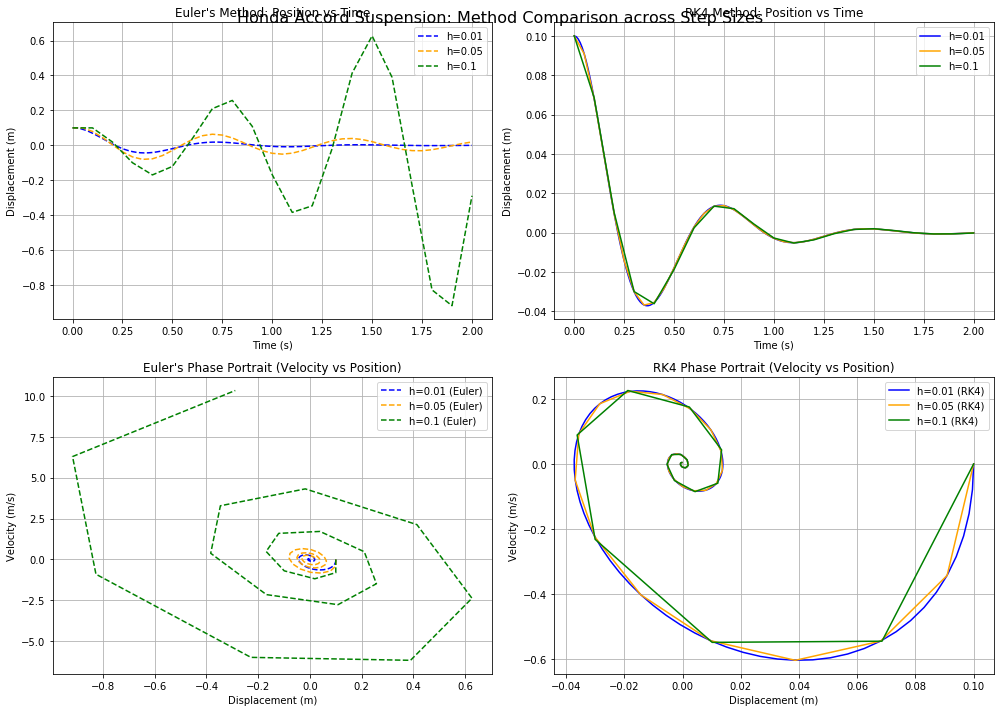

In [3]:
# Section 4
step_sizes = [0.01, 0.05, 0.1]
colors = ['blue', 'orange', 'green']

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Honda Accord Suspension: Method Comparison across Step Sizes', fontsize=16)

for h, color in zip(step_sizes, colors):

    t_eul, Y_eul = euler_method(accord_suspension, y0, t_start, t_end, h)
    t_rk4, Y_rk4 = rk4_method(accord_suspension, y0, t_start, t_end, h)
    
    # euler plot 
    axs[0, 0].plot(t_eul, Y_eul[:, 0], label=f'h={h}', color=color, linestyle='--')
    # rk4 plot
    axs[0, 1].plot(t_rk4, Y_rk4[:, 0], label=f'h={h}', color=color)
    # phase position
    axs[1, 0].plot(Y_eul[:, 0], Y_eul[:, 1], label=f'h={h} (Euler)', color=color, linestyle='--')
    axs[1, 1].plot(Y_rk4[:, 0], Y_rk4[:, 1], label=f'h={h} (RK4)', color=color)

axs[0, 0].set_title("Euler's Method: Position vs Time")
axs[0, 0].set_xlabel("Time (s)")
axs[0, 0].set_ylabel("Displacement (m)")
axs[0, 0].legend()
axs[0, 0].grid()

axs[0, 1].set_title("RK4 Method: Position vs Time")
axs[0, 1].set_xlabel("Time (s)")
axs[0, 1].set_ylabel("Displacement (m)")
axs[0, 1].legend()
axs[0, 1].grid()

axs[1, 0].set_title("Euler's Phase Portrait (Velocity vs Position)")
axs[1, 0].set_xlabel("Displacement (m)")
axs[1, 0].set_ylabel("Velocity (m/s)")
axs[1, 0].legend()
axs[1, 0].grid()

axs[1, 1].set_title("RK4 Phase Portrait (Velocity vs Position)")
axs[1, 1].set_xlabel("Displacement (m)")
axs[1, 1].set_ylabel("Velocity (m/s)")
axs[1, 1].legend()
axs[1, 1].grid()

plt.tight_layout()
plt.show()

### Section 4: Discussion of visual differences between methods
#### Displacement vs. Time (Top Plots)
Euler's Method (Top Left): The largest step size of h=0.1 (green dashed line) fails to simulate a realistic Honda Accord suspension. Instead of settling down to zero, the waves grow significantly larger over time with increasing step sizes. This shows the method becoming numerically unstable. 

RK4 Method (Top Right): All three step sizes smoothly damp down toward zero, showing the system is stabilizing properly.
#### Phase Portraits - Velocity vs. Position (Bottom Plots)
Euler's Method (Bottom Left): A car's suspension losing energy should spiral inward toward the center. The h=0.1 line spirals drastically outward into a jagged shape. This is visual proof that Euler's method's math errors cause it to blow up.
RK4 Method (Bottom Right): All three lines correctly spiral inward, showing the suspension settling to a stop.
#### From these graphs, you can take away that Euler's method blows up and becomes completely unstable at a step size of 0.1. Meanwhile, the RK4 method handles that same step size perfectly, accurately capturing the suspension without spiraling out of control.

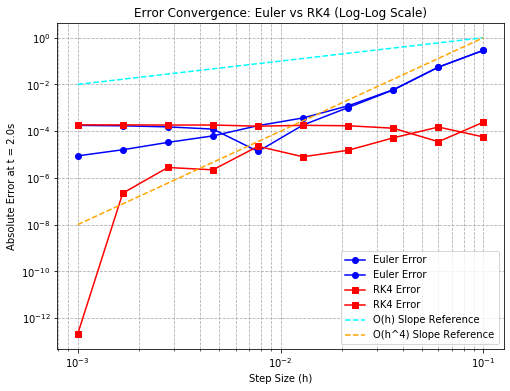

In [4]:
# section 5
# analytical solution
alpha = c / (2 * m)
omega_d = np.sqrt(k / m - alpha**2)

def exact_solution(t):
    return np.exp(-alpha * t) * (y0 * np.cos(omega_d * t) + (alpha * y0 / omega_d) * np.sin(omega_d * t))

# error analysis
h_vals = np.logspace(-3, -1, 10)
error_euler = []
error_rk4 = []

target_time = 2.0
y_exact_target = exact_solution(target_time)

for h in h_vals:
    _, Y_eul = euler_method(accord_suspension, y0, 0, target_time, h)
    _, Y_rk4 = rk4_method(accord_suspension, y0, 0, target_time, h)
    
    error_euler.append(np.abs(Y_eul[-1, 0] - y_exact_target)) ## calculate absolute error
    error_rk4.append(np.abs(Y_rk4[-1, 0] - y_exact_target))

# Log-Log Error Plot
plt.figure(figsize=(8, 6))
plt.loglog(h_vals, error_euler, 'o-', label="Euler Error", color='blue')
plt.loglog(h_vals, error_rk4, 's-', label="RK4 Error", color='red')
plt.loglog(h_vals, 1e1 * h_vals**1, '--', color='cyan', label="O(h) Slope Reference")
plt.loglog(h_vals, 1e4 * h_vals**4, '--', color='orange', label="O(h^4) Slope Reference")

plt.title("Error Convergence: Euler vs RK4 (Log-Log Scale)")
plt.xlabel("Step Size (h)")
plt.ylabel("Absolute Error at t = 2.0s")
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

### Section 5: Discussion of Stable vs. Unstable Behavior
When the simulation is stable, it means the math is working correctly without small errors to make sure the numbers aren't extraneous and give the right answer. RK4 does this very well, but Euler only does it well only if the time steps super tiny. In real life, a stable graph looks exactly like how car suspension works. If I hit a bump in my Honda Accord, the shock absorbs the energy, the bouncing gets smaller, and eventually, the car rides smoothly again.
Now, contrasting when the simulation is unstable, it is taking step sizes that are too big for the computer to handle, making the math essentially break. The small errors pile up and multiply on every single step to make the numbers go crazy and spiral out of control. It doesn't completely translate to a real-world physical application, though, because the math errors are piling up, and the simulation is adding fake energy out of nowhere. If a real car acted like this, hitting a bump would make it bounce higher and higher every time until the car completely fell apart.

### Section 6: Conclusions
*Which method performed better?:* The 4th-Order Runge-Kutta (RK4) method outperformed Euler's Forward method in modeling my Honda Accord's suspension. Euler's method quickly became unstable and generated non-physical ans extraneous results, while the RK4 remained completely stable and highly accurate all throughout.

*Computational Cost vs. Accuracy Tradeoff:* Euler's method is computationally cheap, requiring only one function evaluation per time step, but its O(h) accuracy means we need extremely small step sizes to get a usable result. RK4 requires four function evaluations per time step, which makes it roughly four times as expensive per step, but its O(h^4) accuracy allows us to take much larger steps. Overall, RK4 is more efficient because the succint accuracy easily outweighs the extra computations per step.

*Practical Recommendation?:* If I were programming an onboard computer for a car's active suspension system, I would only recommend RK4. Euler's method is too risky and unreliable for mechanical systems with low damping, as any error in the computer's calculation could cause the software to assume the car is experiencing unnatural forces.

*Lessons Learned:* Through this project, I learned how to translate a theoretical, second-order engineering problem into a system of first-order ODEs that a computer can solve. I also learned that visualizing stability limits and tracking the convergence rates on a log-log plot provides definitive, mathematical proof of why higher-order solvers like RK4 are the industry standard for physical simulations.